In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator


## Load cleaned WASDE data

### WASDE cotton data

In [2]:
CROP = 'cotton'
PROJECT_ROOT = Path('.').resolve().parent                    # .. project root
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed' / f'{CROP}'  # e.g., ../data/processed/cotton/
INPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df_wasde = pd.read_excel(f'{INPUT_DIR}/cotton_1991_2026.xlsx')
df_wasde['time'] = pd.to_datetime(df_wasde.time)

# subset for just the official data released in may
df_wasde_final = df_wasde.query(" time.dt.month == 5 ").reset_index(drop=True)
df_wasde_final = df_wasde_final[[col for col in df_wasde_final if 'current_year_last_month' not in col]]

# for the data that comes out in may, the year_minus_1 column is the official data for the previous growing season
keep_cols = ['time'] + [col for col in df_wasde_final if 'year_minus_1' in col]
df_wasde_final = df_wasde_final[keep_cols].reset_index(drop=True)
df_wasde_final.columns = ['time', 'planted_area', 'harvested_area', 'yield']

# calculate an abandonment rate column
df_wasde_final['abandonment'] = (1 - (df_wasde_final.harvested_area / df_wasde_final.planted_area)) * 100

# and also calculate a yield change column
df_wasde_final['yield_change'] = df_wasde_final.diff(periods=1, axis=0)['yield']

df_wasde_final = df_wasde_final[['time', 'yield', 'yield_change', 'planted_area', 'harvested_area', 'abandonment']]
df_wasde_final


,time,yield,yield_change,planted_area,harvested_area,abandonment
0,1991-05-01,634.0,NaN,12.35,11.73,5.020243
1,1992-05-01,652.0,18.0,14.05,12.96,7.758007
2,1993-05-01,699.0,47.0,13.24,11.14,15.861027
3,1994-05-01,606.0,-93.0,13.44,12.79,4.836310
4,1995-05-01,708.0,102.0,13.73,13.33,2.913328
5,1996-05-01,537.0,-171.0,16.93,16.01,5.434141
6,1997-05-01,707.0,170.0,14.63,12.87,12.030075
7,1998-05-01,680.0,-27.0,13.81,13.27,3.910210
8,1999-05-01,625.0,-55.0,13.39,10.68,20.238984
9,2000-05-01,607.0,-18.0,14.87,13.42,9.751177


Let's verify that the planted and harvested area data that we scraped and processed matches this updated (as of January 12, 2026) figure from the USDA: https://www.nass.usda.gov/Charts_and_Maps/Field_Crops/cotnac.php

<br>
<br>

<img src='../images/usda_cotton_planted_harvested_area.png' width=600 alt='USDA cotton planted and harvested area from 1996 to 2025' />


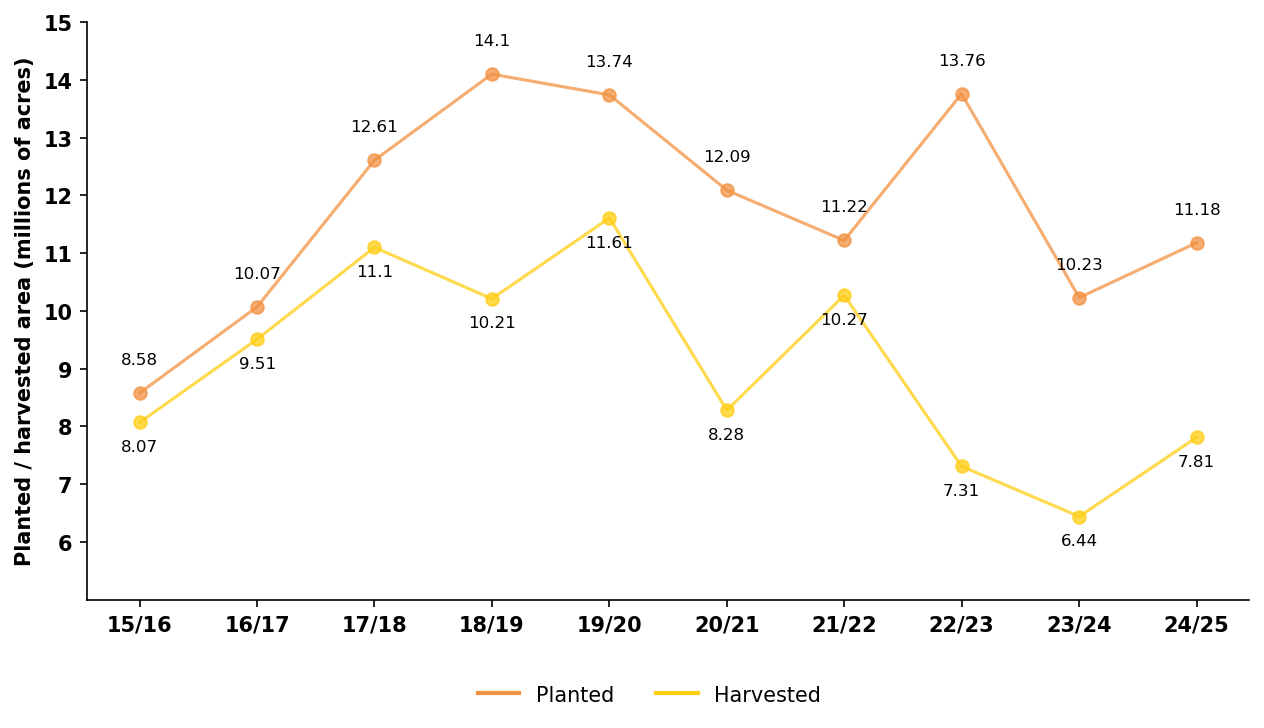

In [4]:
df = df_wasde_final.copy()
df = df.query(" time.dt.year > 2015 ")

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

planted_color = '#f29241'
harvested_color = '#ffcd13'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 2,
}

planted_label = Line2D(label='Planted', color=planted_color, **line_options)
harvested_label = Line2D(label='Harvested', color=harvested_color, **line_options)
legend_elements = [planted_label, harvested_label]

ax.plot(df['time'], df['planted_area'], color=planted_color, alpha=alpha)
ax.scatter(df['time'], df['planted_area'], color=planted_color, alpha=alpha)
ax.plot(df['time'], df['harvested_area'], color=harvested_color, alpha=alpha)
ax.scatter(df['time'], df['harvested_area'], color=harvested_color, alpha=alpha)

for idx in df.index.values:
    time_value = df.loc[idx, 'time']
    planted_value = df.loc[idx, 'planted_area']
    harvested_value = df.loc[idx, 'harvested_area']

    ax.text(time_value, planted_value + 0.5, planted_value, ha='center', size=8)
    ax.text(time_value, harvested_value - 0.5, harvested_value, ha='center', size=8)

xticks = df.time.values
labels = [pd.to_datetime(date) for date in df.time.values]
labels = [f"{str(label.year - 1)[-2:]}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=xticks, labels=labels, fontweight='bold')

yticks = np.arange(6, 16, 1)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_ylim([5, 15])
ax.set_ylabel('Planted / harvested area (millions of acres)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

fig.legend(handles=legend_elements, ncols=len(legend_elements), loc='lower center', bbox_to_anchor=(0.0, -0.055, 1.0, 0.0), frameon=False)

plt.show()


And do the same for the yield: https://www.nass.usda.gov/Charts_and_Maps/Field_Crops/cotnyld.php

<br>
<br>

<img src='../images/usda_cotton_yield.png' width=600 alt='USDA cotton yield from 1996 to 2025' />

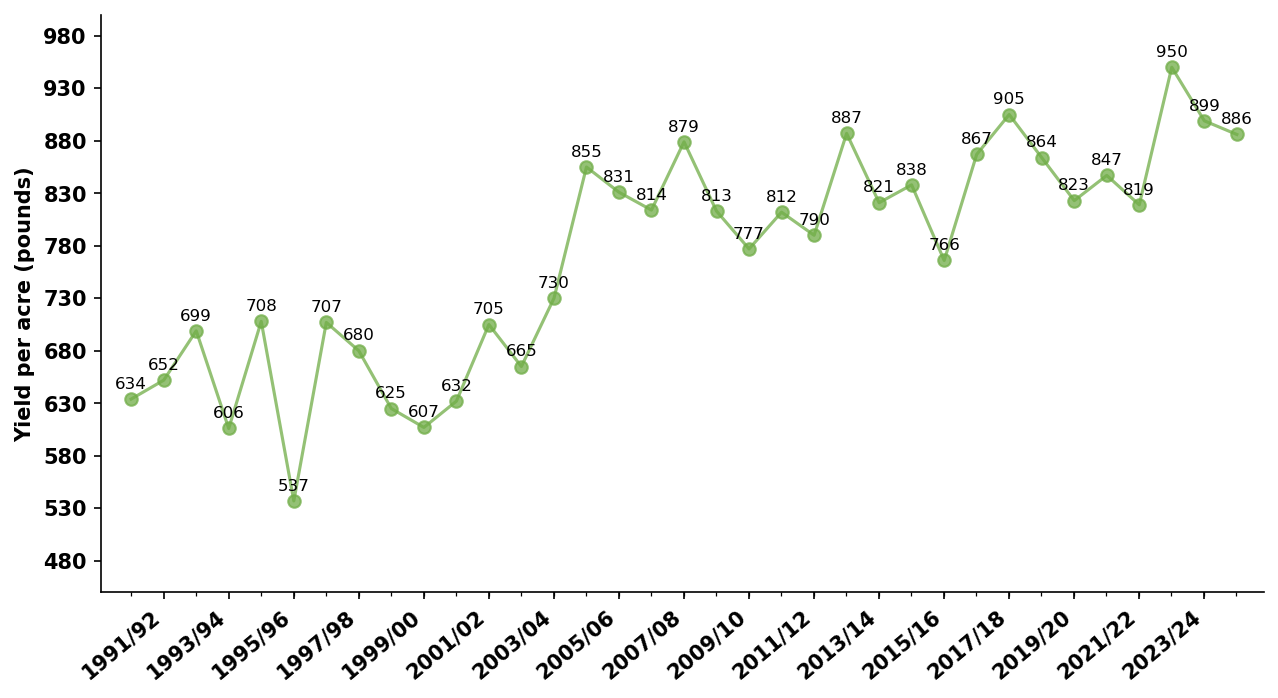

In [5]:
df = df_wasde_final.copy()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

yield_color = '#70ad47'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 2,
}

yield_label = Line2D(label='Yield', color=yield_color, **line_options)
legend_elements = [yield_label]

ax.plot(df['time'], df['yield'], color=yield_color, alpha=alpha)
ax.scatter(df['time'], df['yield'], color=yield_color, alpha=alpha)

for idx in df.index.values:
    time_value = df.loc[idx, 'time']
    yield_value = int(df.loc[idx, 'yield'])

    ax.text(time_value, yield_value + 10, yield_value, ha='center', size=8)

xticks = df.time.values[1::2]
labels = [pd.to_datetime(date) for date in df.time.values[1::2]]
labels = [f"{label.year - 1}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=xticks, labels=labels, fontweight='bold')

yticks = np.arange(480, 1030, 50)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.tick_params(axis='x', rotation=40)
for ticklabel in ax.get_xticklabels():
    ticklabel.set_horizontalalignment('right')

ax.set_xlim([pd.to_datetime('1990-06-01'), pd.to_datetime('2026-03-01')])
ax.set_ylim([450, 1000])
ax.set_ylabel('Yield per acre (pounds)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

# fig.legend(handles=legend_elements, ncols=len(legend_elements), loc='lower center', bbox_to_anchor=(0.0, -0.095, 1.0, 0.0), frameon=False)

plt.show()


As a last check, we can compare our abandonment rate calculations to those provided in a table (limited to the past four years) in the USDA's cotton outlook published in February 2005: https://www.usda.gov/sites/default/files/documents/2025AOF-cotton-outlook.pdf#page=8

<style>
    table { 
        margin-left: 0; 
        width: 100%;
    }
</style>

**U.S. Cotton Area, Abandonment, Yield, and Production**
|                    | Unit          | 2020/21 | 2021/22 | 2022/23 | 2023/24 | 2024/25* |
| :------------------| ------------- | :-----: | :-----: | :-----: | :-----: | :-----:  |
Planted acres        | mil. Acres    | 12.1    | 11.2    | 13.7    | 10.2    | 11.2     |
Harvested acres      | mil. Acres    | 8.2     | 10.3    | 7.3     | 6.4     | 8.3      |
Abandonment rate     | %             | 32.1    | 8.4     | 47.0    | 37.1    | 26.0     |
Yield/harvested acre | lbs./acre     | 854     | 820     | 953     | 899     | 836      |
Production           | mil. Bales    | 14.6    | 17.5    | 14.5    | 12.1    | 14.4     |

**\* preliminary data**


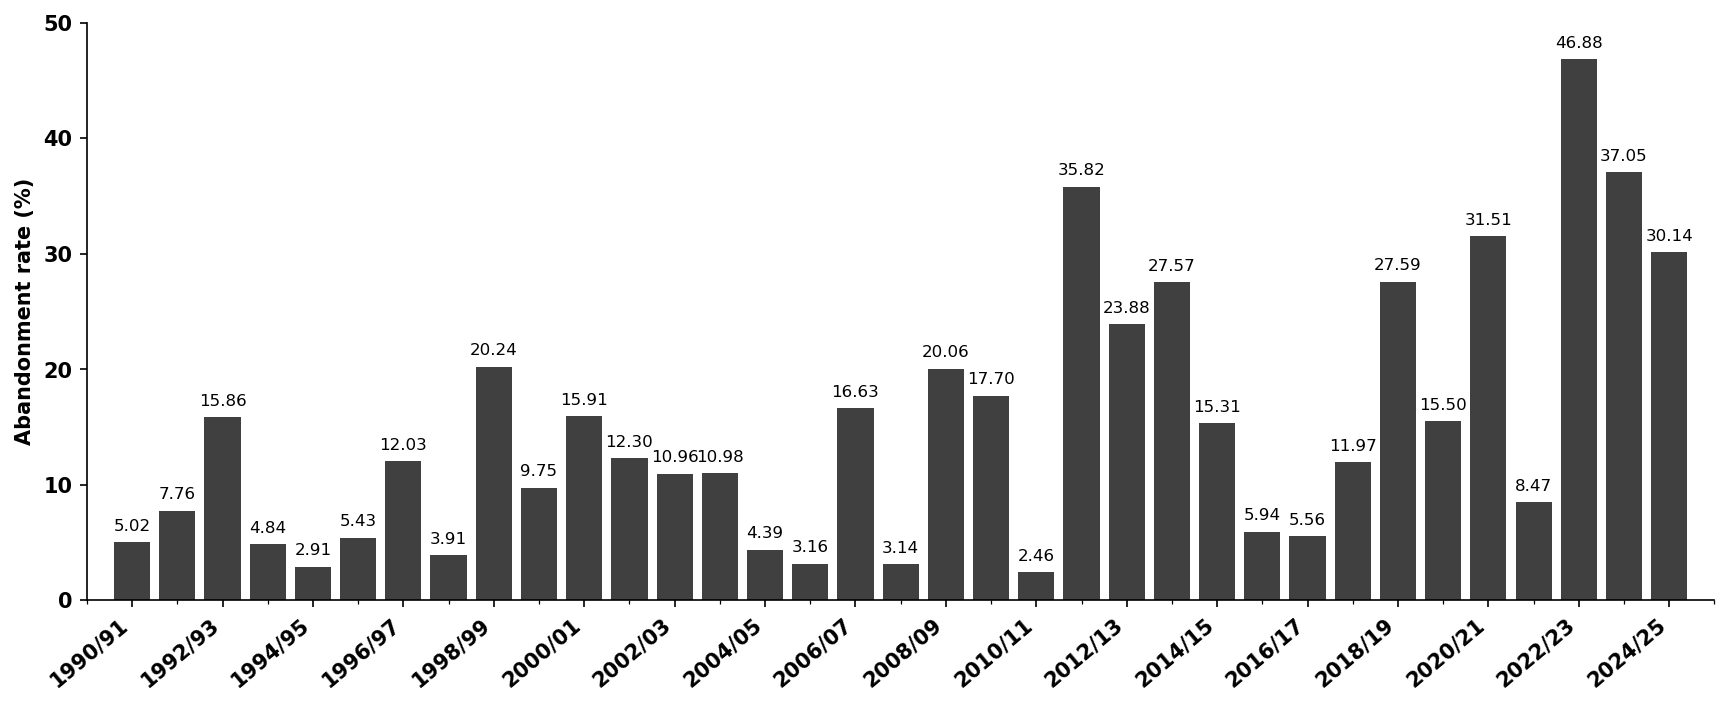

In [6]:
df = df_wasde_final.copy()

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

abandonment_color = 'black'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 6,
    'alpha': alpha,
}

abandonment_label = Line2D(label='Abandonment', color=abandonment_color, **line_options)
legend_elements = [abandonment_label]

ax.bar(df.index, df['abandonment'], color=abandonment_color, alpha=alpha)

for idx in df.index.values:
    abandonment_value = df.loc[idx, 'abandonment']
    ax.text(idx, abandonment_value + 1, f"{abandonment_value:.02f}", ha='center', size=8)

ticks = list(range(0, 35, 2))
labels = [pd.to_datetime(date) for date in df.loc[[idx for idx in ticks]].time.values]
labels = [f"{label.year - 1}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=ticks, labels=labels, fontweight='bold')

yticks = np.arange(0, 60, 10)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')

ax.xaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(axis='x', rotation=40)
for ticklabel in ax.get_xticklabels():
    ticklabel.set_horizontalalignment('right')

ax.set_xlim([-1, 35])
ax.set_ylim([0, 50])
ax.set_ylabel('Abandonment rate (%)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

plt.show()


We can see that our abandonment rate data is matching the data provided by the USDA for cotton for the 2020/21, 2021/22, 2022/23, and 2023/24 growing seasons. The USDA data for the 2024/25 data is preliminary, since the data came before the close of the growing season, so I am not too concerned about the mismatch here.

It looks like the data we aggregated matches that used by the USDA in official reports and dashboards.